# Vechta - Mapping

In [1]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [3]:
client = bigquery.Client(project='subugoe-collaborative')

In [6]:
oal = client.query(f"""
                    SELECT 
                        'not assigned' AS fak_name,
                        'Universität Vechta' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202603` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202603` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.ror = 'https://ror.org/045y6d111' -- 'Universität Vechta'
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [7]:
oal.head()

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,Universität Vechta,"Chair of Business and Ethics, University of Ve...",https://openalex.org/W4206715154
1,not assigned,Universität Vechta,"Universität , Vechta Germany",https://openalex.org/W4292607636
2,not assigned,Universität Vechta,"Department of Gerontology, University of Vecht...",https://openalex.org/W4281720818
3,not assigned,Universität Vechta,"Department of Educational Psychology, Universi...",https://openalex.org/W4283813336
4,not assigned,Universität Vechta,Department of Educational Psychology Universit...,https://openalex.org/W4283813336


In [77]:
MAPPING_DICT = {
    #'Bildung, Erziehung, Gesellschaft: Vechta-Institut für Inklusion': [],
    'Vechta Institute of Sustainability Transformation in Rural Areas': ['rural areas', 'sustainability transformation'],
    'Fakultät I': ['department of education', 'erziehungswissenschaften', 'gerontolog(ie|y)', 'soziale arbeit', 'education and social',
                   'psychology', '(faculty|department) (?<!i)i,', '(?<!natural and\s)(educational|soci(a|eta)l) science', 'social work', 'gesellschaftswissenschaften', 'ethics',
                   'economics and sustainability', 'pedagogy', 'inclusion', 'sociology'
                  ],
    'Fakultät II': ['germanisti(k|sch)', 'geography', 'geo(-|‐|\s)lab', 'biology', '(faculty|department) ii', 'sport',
                    'english', 'schulpädagogik', 'cultural (sciences|studies)', 'landschaftsökologie', 'landscape ecology',
                    'kulturwissenschaften', 'natur- und sozialwissenschaften', 'agriculture', 'media research', 'geschichte', 
                    'history', 'faculty of natural', 'training and movement'
                   ],
    'Zentrum für Lehrer*innenbildung': ['teacher training']
}

In [78]:
with open('./mapping_tables_fak/vechta.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT, f, ensure_ascii=False)

In [79]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [80]:
df_with_inst = oal.copy()

df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned', 'fak_name'] = \
           df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [81]:
df_with_inst

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,Fakultät I,Universität Vechta,"Chair of Business and Ethics, University of Ve...",https://openalex.org/W4206715154
1,None,Universität Vechta,"Universität , Vechta Germany",https://openalex.org/W4292607636
2,Fakultät I,Universität Vechta,"Department of Gerontology, University of Vecht...",https://openalex.org/W4281720818
3,Fakultät I,Universität Vechta,"Department of Educational Psychology, Universi...",https://openalex.org/W4283813336
4,Fakultät I,Universität Vechta,Department of Educational Psychology Universit...,https://openalex.org/W4283813336
...,...,...,...,...
576,Fakultät I,Universität Vechta,"Department of Education, Faculty of Education ...",https://openalex.org/W3010507001
577,None,Universität Vechta,Universität Vechta Deutschland,https://openalex.org/W4307560926
578,None,Universität Vechta,Universität Vechta,https://openalex.org/W4386541196
579,Fakultät I,Universität Vechta,"Institut für Gerontologie , Universität Vechta...",https://openalex.org/W4295008679


In [82]:
df_with_inst[df_with_inst.fak_name.isnull()].raw_affiliation_string.unique()

array(['Universität , Vechta Germany', 'University of Vechta, Germany',
       'University of Vechta, Driverstr. 22, 49364 Vechta, Germany',
       'Universität Vechta',
       'Universität Vechta Driverstraße 22 49377 Vechta/D',
       'University of Vechta, Vechta, Germany',
       'University of Vechta , Vechta ,',
       'University of Vechta, 49377, Vechta, Germany',
       'University of Vechta Vechta Germany',
       'Universität Vechta Vechta Deutschland',
       'Universität Vechta  Driverstr. 22 49377 Vechta',
       'Unversity of Vechta , Vechta, Niedersachsen , Germany',
       'University of Vechta',
       'an der Universität Vechta mit Schwerpunkten Beratung, professionelle Reflexion, Kriminalprävention und Autorin entsprechender',
       'Dozentin für Journalmethoden an der Universität Vechta, im',
       'University Vechta', 'University of Vechta, 49377 Vechta, Germany',
       'University of Vechta, Driverstraße 22, 49377, Vechta, Germany',
       'University of Vecht

In [83]:
df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()

,fak_name,openalex_id
0,Fakultät I,148
1,Fakultät II,147
2,Vechta Institute of Sustainability Transformat...,33
3,Zentrum für Lehrer*innenbildung,2
4,NaN,251


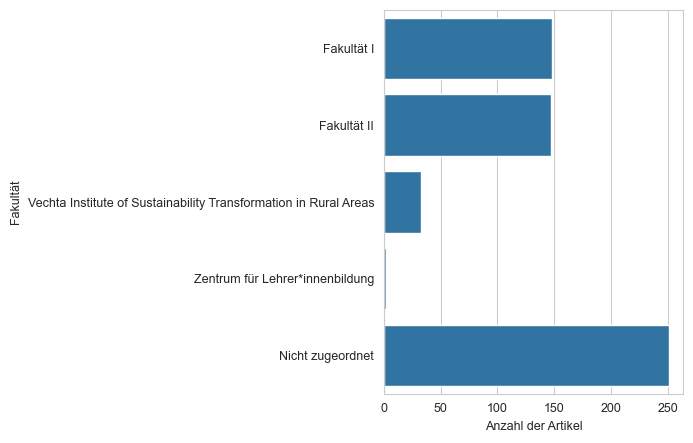

In [84]:
df_plot = df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='fak_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [85]:
df_plot[df_plot.fak_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.5679862306368331

In [87]:
MAPPING_DICT_DEPT = {
    'Fakultät I': {
        'Fach Erziehungswissenschaften': ['erziehungswissenschaften', 'educational sciences', 'department of education', 'primary school'],
        'Fach Gerontologie': ['gerontolog(ie|y)'],
        'Fach Management sozialer Dienstleistungen': ['sozialer dienstleistungen', 'business (and )?ethics', 'social services management'],
        'Fach Soziale Arbeit': ['soziale arbeit', 'social work'],
        'Fach Soziologie': ['so(z|c)iolog(ie|y)'],
        'Fach Sustainability, Entrepreneurship and Innovation': ['entrepreneurship', 'sustainability'],
        'Lehr- und Forschungseinheit Pädagogische Psychologie': ['psycholog(ie|y)'],
    },
    'Fakultät II': {
        'Fach Anglistik': ['anglistik', 'english linguistics', 'department of english', 'english department'],
        'Fach Biologie': ['biolog(ie|y)'],
        'Fach Designpädagogik': ['designpädagogik'],
        'Fach Geographie': ['geograph(ie|y)', 'landscape', 'geo(-|‐|\s)lab', 'landschaftsökologie', 'agriculture'],
        'Fach Germanistik': ['germanisti(k|sch)'],
        'Fach Geschichtswissenschaft': ['geschichtswissenschaft', 'history', 'geschichte'],
        'Fach Katholische Theologie': ['katholische theologie', 'catholic'],
        'Fach Kulturwissenschaften': ['kulturwissenschaften', 'cultural (studies|sciences)', 'media research'],
        'Fach Mathematik': ['mathematik'],
        'Fach Musik': ['musi(k|c)'],
        'Fach Philosophie': ['philosoph(ie|y)'],
        'Fach Politikwissenschaft': ['politikwissenschaft'],
        'Fach Sachunterricht': ['sachunterricht', 'didaktik'],
        'Fach Sportwissenschaft': ['sport(s)?(\s)?science', 'sportwissenschaft', 'training and movement'],
    }
}

In [88]:
with open('./mapping_tables_dept/vechta.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT_DEPT, f, ensure_ascii=False)

In [89]:
def map_dept(address: str, faculty: str) -> Union[str, None]:
    if faculty in MAPPING_DICT_DEPT:
        for k, v in MAPPING_DICT_DEPT.get(faculty).items():
            pattern = re.compile(r'|'.join(v), re.IGNORECASE)
            res = bool(pattern.search(address))
            if res:
                return k
        return None
    else:
        return None

In [90]:
df_with_inst.loc[df_with_inst['fak_name'] == 'Fakultät II', 'dept_name'] = \
    df_with_inst.loc[df_with_inst['fak_name'] == 'Fakultät II']['raw_affiliation_string'].apply(map_dept, 
                                                                        faculty='Fakultät II')

In [91]:
df_with_inst[(df_with_inst['fak_name'] == 'Fakultät II') & df_with_inst['dept_name'].isnull()].raw_affiliation_string.unique()[:20]

array(['Faculty of Natural and Social Sciences, University of Vechta, Driverstraße 22, D-49377 Vechta, Germany',
       'University of Vechta, Faculty II',
       'Faculty of Natural and Social Sciences, University of Vechta, Vechta, Germany',
       'Faculty II, University of Vechta, Vechta, Germany',
       'Department II - Natural and Social Sciences, University of Vechta, Vechta, Germany',
       'Faculty II, University of Vechta, Driverstr. 22, D-49377, Vechta, Germany',
       'Fakultät Natur- und Sozialwissenschaften, Universität Vechta, Vechta, Deutschland',
       'Fakultät Natur- und Sozialwissenschaften, Universität Vechta, Kreuzweg 3–5, 49377, Vechta, Deutschland'],
      dtype=object)

In [92]:
df_with_inst[df_with_inst['fak_name'] == 'Fakultät II'].groupby(['dept_name'], dropna=False)['openalex_id'].count().reset_index()

,dept_name,openalex_id
0,Fach Anglistik,4
1,Fach Biologie,7
2,Fach Geographie,69
3,Fach Germanistik,15
4,Fach Geschichtswissenschaft,4
5,Fach Katholische Theologie,1
6,Fach Kulturwissenschaften,9
7,Fach Sachunterricht,2
8,Fach Sportwissenschaft,23
9,NaN,13


In [93]:
df_with_inst[df_with_inst['fak_name'] == 'Fakultät II']

,fak_name,parent_name,raw_affiliation_string,openalex_id,dept_name
6,Fakultät II,Universität Vechta,"Department of Geography, Faculty II, Universit...",https://openalex.org/W4225158334,Fach Geographie
8,Fakultät II,Universität Vechta,"Cultural Sciences, University of Vechta, Germany",https://openalex.org/W4214876516,Fach Kulturwissenschaften
13,Fakultät II,Universität Vechta,"Present address: Department of Biology, Facult...",https://openalex.org/W4206921329,Fach Biologie
23,Fakultät II,Universität Vechta,"Department of Sports Science, University of Ve...",https://openalex.org/W4205604287,Fach Sportwissenschaft
34,Fakultät II,Universität Vechta,"Department of Sport Science, University of Vec...",https://openalex.org/W4284666130,Fach Sportwissenschaft
...,...,...,...,...,...
552,Fakultät II,Universität Vechta,"Universität Vechta, Germanistische Sprachwisse...",https://openalex.org/W3177488520,Fach Germanistik
556,Fakultät II,Universität Vechta,"Chair of Landscape Ecology, University of Vech...",https://openalex.org/W3165742911,Fach Geographie
563,Fakultät II,Universität Vechta,"Universität Vechta , Germanistische Sprachwiss...",https://openalex.org/W3173180364,Fach Germanistik
566,Fakultät II,Universität Vechta,"Institute for Applied Physical Geography, Univ...",https://openalex.org/W3172256479,Fach Geographie
